<a href="https://colab.research.google.com/github/wjarret/Thesis_Code_Book/blob/main/04092026_creating_sliding_window.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In this document, I will be creating a dataset consisting of 16 nucleotide chunks of snRNA RNP-MaP data. To do this, starting at the begining of every seqeunce, for every 16 nucloetides, create its own data frame consisting of all RNP-MaP data, labeled with a unique name. After each window is created, dimensionality reduction will be used to assess variation. Steps:

> Create function that uses a sliding window to get all possible 16 window combinations and label each one based off of seqeunce identity.
>
> Apply function across all datasets.
>
> Run a PCA on all data and potentionally hierarchical clustering
>
> Analyze output



In [97]:
# Clone the repository using your token

import shutil
import subprocess
import os

shutil.copy("/content/drive/MyDrive/Colab Code/04092026_creating_sliding_window.ipynb",
            "/content/Thesis_Code_Book/04092026_creating_sliding_window.ipynb")

os.chdir("/content/Thesis_Code_Book")
subprocess.run(["git", "remote", "set-url", "origin", repo])
subprocess.run(["git", "add", "."])
subprocess.run(["git", "commit", "-m", "04092026_sliding_window Version 1"])
result = subprocess.run(["git", "push", "origin", "main"], capture_output=True, text=True)
print(result.stdout)
print(result.stderr)


To https://github.com/wjarret/Thesis_Code_Book.git
   57bf9dd..db86dd1  main -> main



In [93]:
import subprocess
result = subprocess.run(["find", "/content/drive/MyDrive", "-name", "*.ipynb"],
                       capture_output=True, text=True)
print(result.stdout)

/content/drive/MyDrive/Colab Notebooks/Pivot_tables.ipynb
/content/drive/MyDrive/Colab Notebooks/Date_Time_Functionality.ipynb
/content/drive/MyDrive/Colab Notebooks/notebook_1.ipynb
/content/drive/MyDrive/Colab Notebooks/notebook_1_my_copy.ipynb
/content/drive/MyDrive/Colab Notebooks/HW_3_Jarrett.ipynb
/content/drive/MyDrive/Colab Notebooks/notebook_12.ipynb
/content/drive/MyDrive/Colab Notebooks/501 Notes/Lecture_notes_export (Unzipped Files)/notebook_2.ipynb
/content/drive/MyDrive/Colab Notebooks/501 Notes/Lecture_notes_export (Unzipped Files)/notebook_5.ipynb
/content/drive/MyDrive/Colab Notebooks/501 Notes/Lecture_notes_export (Unzipped Files)/notebook_3.ipynb
/content/drive/MyDrive/Colab Notebooks/501 Notes/Lecture_notes_export (Unzipped Files)/notebook_1.ipynb
/content/drive/MyDrive/Colab Notebooks/501 Notes/Lecture_notes_export (Unzipped Files)/notebook_4.ipynb
/content/drive/MyDrive/Colab Notebooks/501 Notes/Lecture_notes_export (Unzipped Files)/notebook_6.ipynb
/content/drive

In [ ]:
#Librarys
import os
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn import preprocessing
from google.colab import data_table
data_table.enable_dataframe_formatter()
from matplotlib import pyplot as plt
import seaborn as sns
from google.colab import drive
drive.flush_and_unmount()
drive.mount('/content/drive', force_remount=True)

# Install itables if not already installed
!pip install itables

import itables
from itables import init_notebook_mode
init_notebook_mode()
#Directory
PATH = '/content/drive/My Drive/Data/RNP_MaP_CSVs'
os.chdir(PATH)
os.listdir()

Mounted at /content/drive
shell-init: error retrieving current directory: getcwd: cannot access parent directories: Transport endpoint is not connected
shell-init: error retrieving current directory: getcwd: cannot access parent directories: Transport endpoint is not connected
Traceback (most recent call last):
  File "/usr/local/bin/pip3", line 4, in <module>
    from pip._internal.cli.main import main
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/main.py", line 11, in <module>
    from pip._internal.cli.autocompletion import autocomplete
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/autocompletion.py", line 10, in <module>
    from pip._internal.cli.main_parser import create_main_parser
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/main_parser.py", line 9, in <module>
    from pip._internal.build_env import get_runnable_pip
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/build_env.py", line 19, in <module>
    

['HeLa-U1_DMSO_aq_SDA_int_20260129_ASV1_profile_RESULTS.csv',
 'HeLa-U5_DMSO_aq_SDA_int_20260129_U5B_profile_RESULTS.csv',
 'HeLa-U5_DMSO_aq_SDA_int_20260129_U5A_profile_RESULTS.csv',
 'HeLa-U4atac_DMSO_aq_SDA_int_20260129_ASV1_profile_RESULTS.csv',
 'HeLa-U4_DMSO_aq_SDA_int_20260129_U4-2_profile_RESULTS.csv',
 'HeLa-U4_DMSO_aq_SDA_int_20260129_U4-1_profile_RESULTS.csv',
 'HeLa-U12_DMSO_aq_SDA_int_20260129_ASV1_profile_RESULTS.csv',
 'HeLa-U11_DMSO_aq_SDA_int_20260129_ASV1_profile_RESULTS.csv',
 'HeLa-U1_DMSO_aq_SDA_int_11092024_ASV1_profile_RESULTS.csv',
 'HeLa-U2_DMSO_aq_SDA_int_110924_ASV1_profile_RESULTS.csv',
 'HeLa-U11_DMSO_aq_SDA_int_110924_ASV1_profile_RESULTS.csv',
 'HeLa-U12_DMSO_aq_SDA_int_110924_ASV1_profile_RESULTS.csv',
 'HeLa-U1_DMSO_aq_SDA_int_20250525_ASV1_profile_RESULTS.csv',
 'HeLa-U1_DMSO_aq_SDA_int_20250707_ASV2_profile_RESULTS.csv',
 'HeLa-U11_DMSO_aq_SDA_int_20250707_ASV1_profile_RESULTS.csv',
 'HeLa-U12_DMSO_aq_SDA_int_20250707_ASV1_profile_RESULTS.csv',
 'HeLa

Loading in snRNA Data Frames

In [ ]:
#20260129
U1_DMSO_aq_SDA_int_20260129 = pd.read_csv('HeLa-U1_DMSO_aq_SDA_int_20260129_ASV1_profile_RESULTS.csv')
U11_DMSO_aq_SDA_int_20260129 = pd.read_csv('HeLa-U11_DMSO_aq_SDA_int_20260129_ASV1_profile_RESULTS.csv')
U12_DMSO_aq_SDA_int_20260129 = pd.read_csv('HeLa-U12_DMSO_aq_SDA_int_20260129_ASV1_profile_RESULTS.csv')
U4_1_DMSO_aq_SDA_int_20260129 = pd.read_csv('HeLa-U4_DMSO_aq_SDA_int_20260129_U4-1_profile_RESULTS.csv')
U4_2_DMSO_aq_SDA_int_20260129 = pd.read_csv('HeLa-U4_DMSO_aq_SDA_int_20260129_U4-2_profile_RESULTS.csv')
U4_atac_DMSO_aq_SDA_int_20260129 = pd.read_csv('HeLa-U4atac_DMSO_aq_SDA_int_20260129_ASV1_profile_RESULTS.csv')
U5A_DMSO_aq_SDA_int_20260129 = pd.read_csv('HeLa-U5_DMSO_aq_SDA_int_20260129_U5A_profile_RESULTS.csv')
U5B_DMSO_aq_SDA_int_20260129 = pd.read_csv('HeLa-U5_DMSO_aq_SDA_int_20260129_U5B_profile_RESULTS.csv')
#07/07/2025
U1_DMSO_aq_SDA_int_20250707 = pd.read_csv('HeLa-U1_DMSO_aq_SDA_int_20250707_ASV2_profile_RESULTS.csv')
U2_DMSO_aq_SDA_int_20250707 = pd.read_csv('HeLa-U2_DMSO_aq_SDA_int_20250707_ASV1_profile_RESULTS.csv')
U11_DMSO_aq_SDA_int_20250707 = pd.read_csv('HeLa-U11_DMSO_aq_SDA_int_20250707_ASV1_profile_RESULTS.csv')
U12_DMSO_aq_SDA_int_20250707 = pd.read_csv('HeLa-U12_DMSO_aq_SDA_int_20250707_ASV1_profile_RESULTS.csv')
#05/05/2025
U1_DMSO_aq_SDA_int_20250525 = pd.read_csv('HeLa-U1_DMSO_aq_SDA_int_20250525_ASV1_profile_RESULTS.csv')
#11/09/24
U1_DMSO_aq_SDA_int_11092024 = pd.read_csv('HeLa-U1_DMSO_aq_SDA_int_11092024_ASV1_profile_RESULTS.csv')
U2_DMSO_aq_SDA_int_11092024 = pd.read_csv('HeLa-U2_DMSO_aq_SDA_int_110924_ASV1_profile_RESULTS.csv')
U11_DMSO_aq_SDA_int_11092024 = pd.read_csv('HeLa-U11_DMSO_aq_SDA_int_110924_ASV1_profile_RESULTS.csv')
U12_DMSO_aq_SDA_int_11092024 = pd.read_csv('HeLa-U12_DMSO_aq_SDA_int_110924_ASV1_profile_RESULTS.csv')

print(len(U11_DMSO_aq_SDA_int_11092024))

#Data Dictionary

D_D = {
    'U1.1':  U1_DMSO_aq_SDA_int_11092024,
    'U1.2':  U1_DMSO_aq_SDA_int_20250525,
    'U1.3':  U1_DMSO_aq_SDA_int_20250707,
    'U1.4':  U1_DMSO_aq_SDA_int_20260129,
    'U2.1':  U2_DMSO_aq_SDA_int_11092024,
    'U2.2':  U2_DMSO_aq_SDA_int_20250707,
    'U11.1': U11_DMSO_aq_SDA_int_11092024,
    'U11.2': U11_DMSO_aq_SDA_int_20250707,
    'U11.3': U11_DMSO_aq_SDA_int_20260129,
    'U12.1': U12_DMSO_aq_SDA_int_11092024,
    'U12.2': U12_DMSO_aq_SDA_int_20250707,
    'U12.3': U12_DMSO_aq_SDA_int_20260129,
    'U4-1': U4_1_DMSO_aq_SDA_int_20260129,
    'U4-2': U4_2_DMSO_aq_SDA_int_20260129,
    'U4atac': U4_atac_DMSO_aq_SDA_int_20260129,
    'U5A': U5A_DMSO_aq_SDA_int_20260129,
    'U5B': U5B_DMSO_aq_SDA_int_20260129
}



128


Creating function

In [ ]:
def sliding_window(data,window_size,step):
  d = {}
  for key, df in data.items():
    n = len(df)
    for i in range(0,n-window_size+1,step):
      window = df.iloc[i:window_size+i]
      identity = f'{key}_{i}:{window_size+i}'
      d[identity] = window
  return d



In [ ]:
window = sliding_window(D_D,16,1)

#This function is used to isolate the Norm_Score from each dataframe in the list. The new list is then concatenated into a single dataframe for PCA.
d = {}
for key, df in window.items():
    df = df[['Norm_Score']]
    identifier = f'{key}'
    d[identifier] = df
PCA_dataframe = pd.concat(d)
PCA_dataframe = PCA_dataframe.reset_index() # Assign the result back to PCA_dataframe
# PCA_dataframe_edit = PCA_dataframe[['level_0','Norm_Score']]
# PCA_dataframe_edit = PCA_dataframe_edit.set_index('level_0')
#pca_matrix.head(25)

PCA Analysis

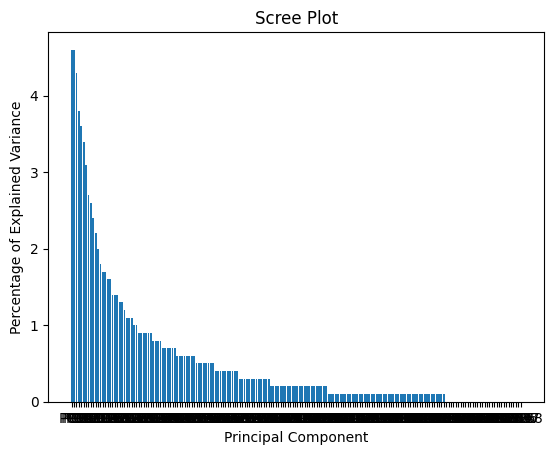

In [ ]:
#PCA
pca_matrix=PCA_dataframe.pivot(index='level_0',columns = 'level_1',values ='Norm_Score')
pca_matrix = pca_matrix.fillna(0)
scaling = preprocessing.scale(pca_matrix)
pca_matrix.head()
pca = PCA()
pca.fit(scaling)
pca_scores = pca.transform(scaling)
per_var = np.round(pca.explained_variance_ratio_ * 100, decimals=1)
labels = ['PC' + str(x) for x in range(1, len(per_var) + 1)]
plt.bar(x=range(1, len(per_var) + 1), height=per_var, tick_label=labels)
plt.ylabel('Percentage of Explained Variance')
plt.xlabel('Principal Component')
plt.title('Scree Plot')
plt.show()



Looking at the scree plot, the majority of the variance is not explained in the first two principle components. When this is the case, the data is viewed as highly complex. To deal with this, I will be using Uniform Manifold Approximaiton and Projection (UMAP). When considering other techniques, t-SNE is the other options, t-SNE could also be used. Because of its reduced speed, reduced interpretability, and being computationally expensive, UMAP sets out to be a better option.

UMAP works

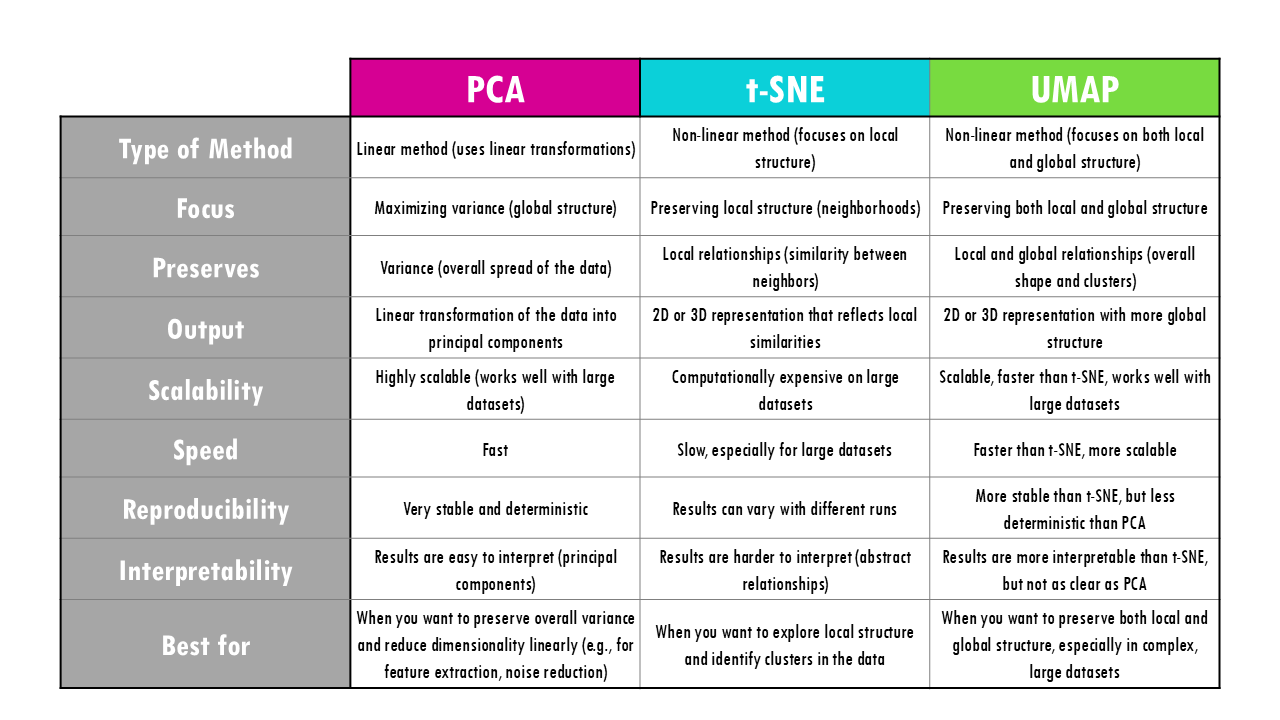

Text(0, 0.5, 'Cumulative Explained Variance')

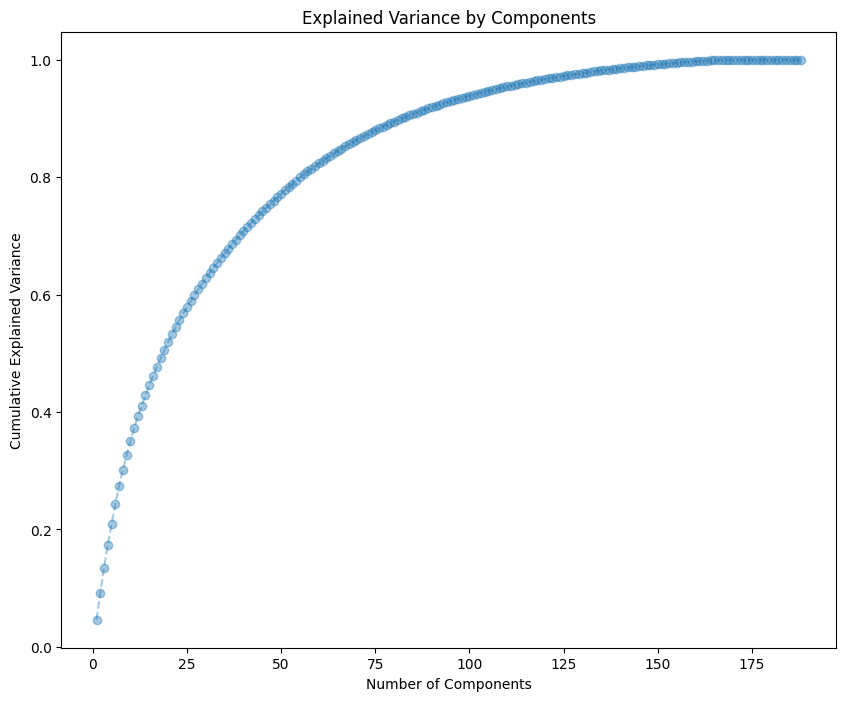

In [ ]:

plt.figure( figsize = (10,8))
plt.plot(range(1,len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_.cumsum(), marker = 'o', linestyle = '--', alpha=0.4)
plt.title("Explained Variance by Components")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")

PCA scatter plot

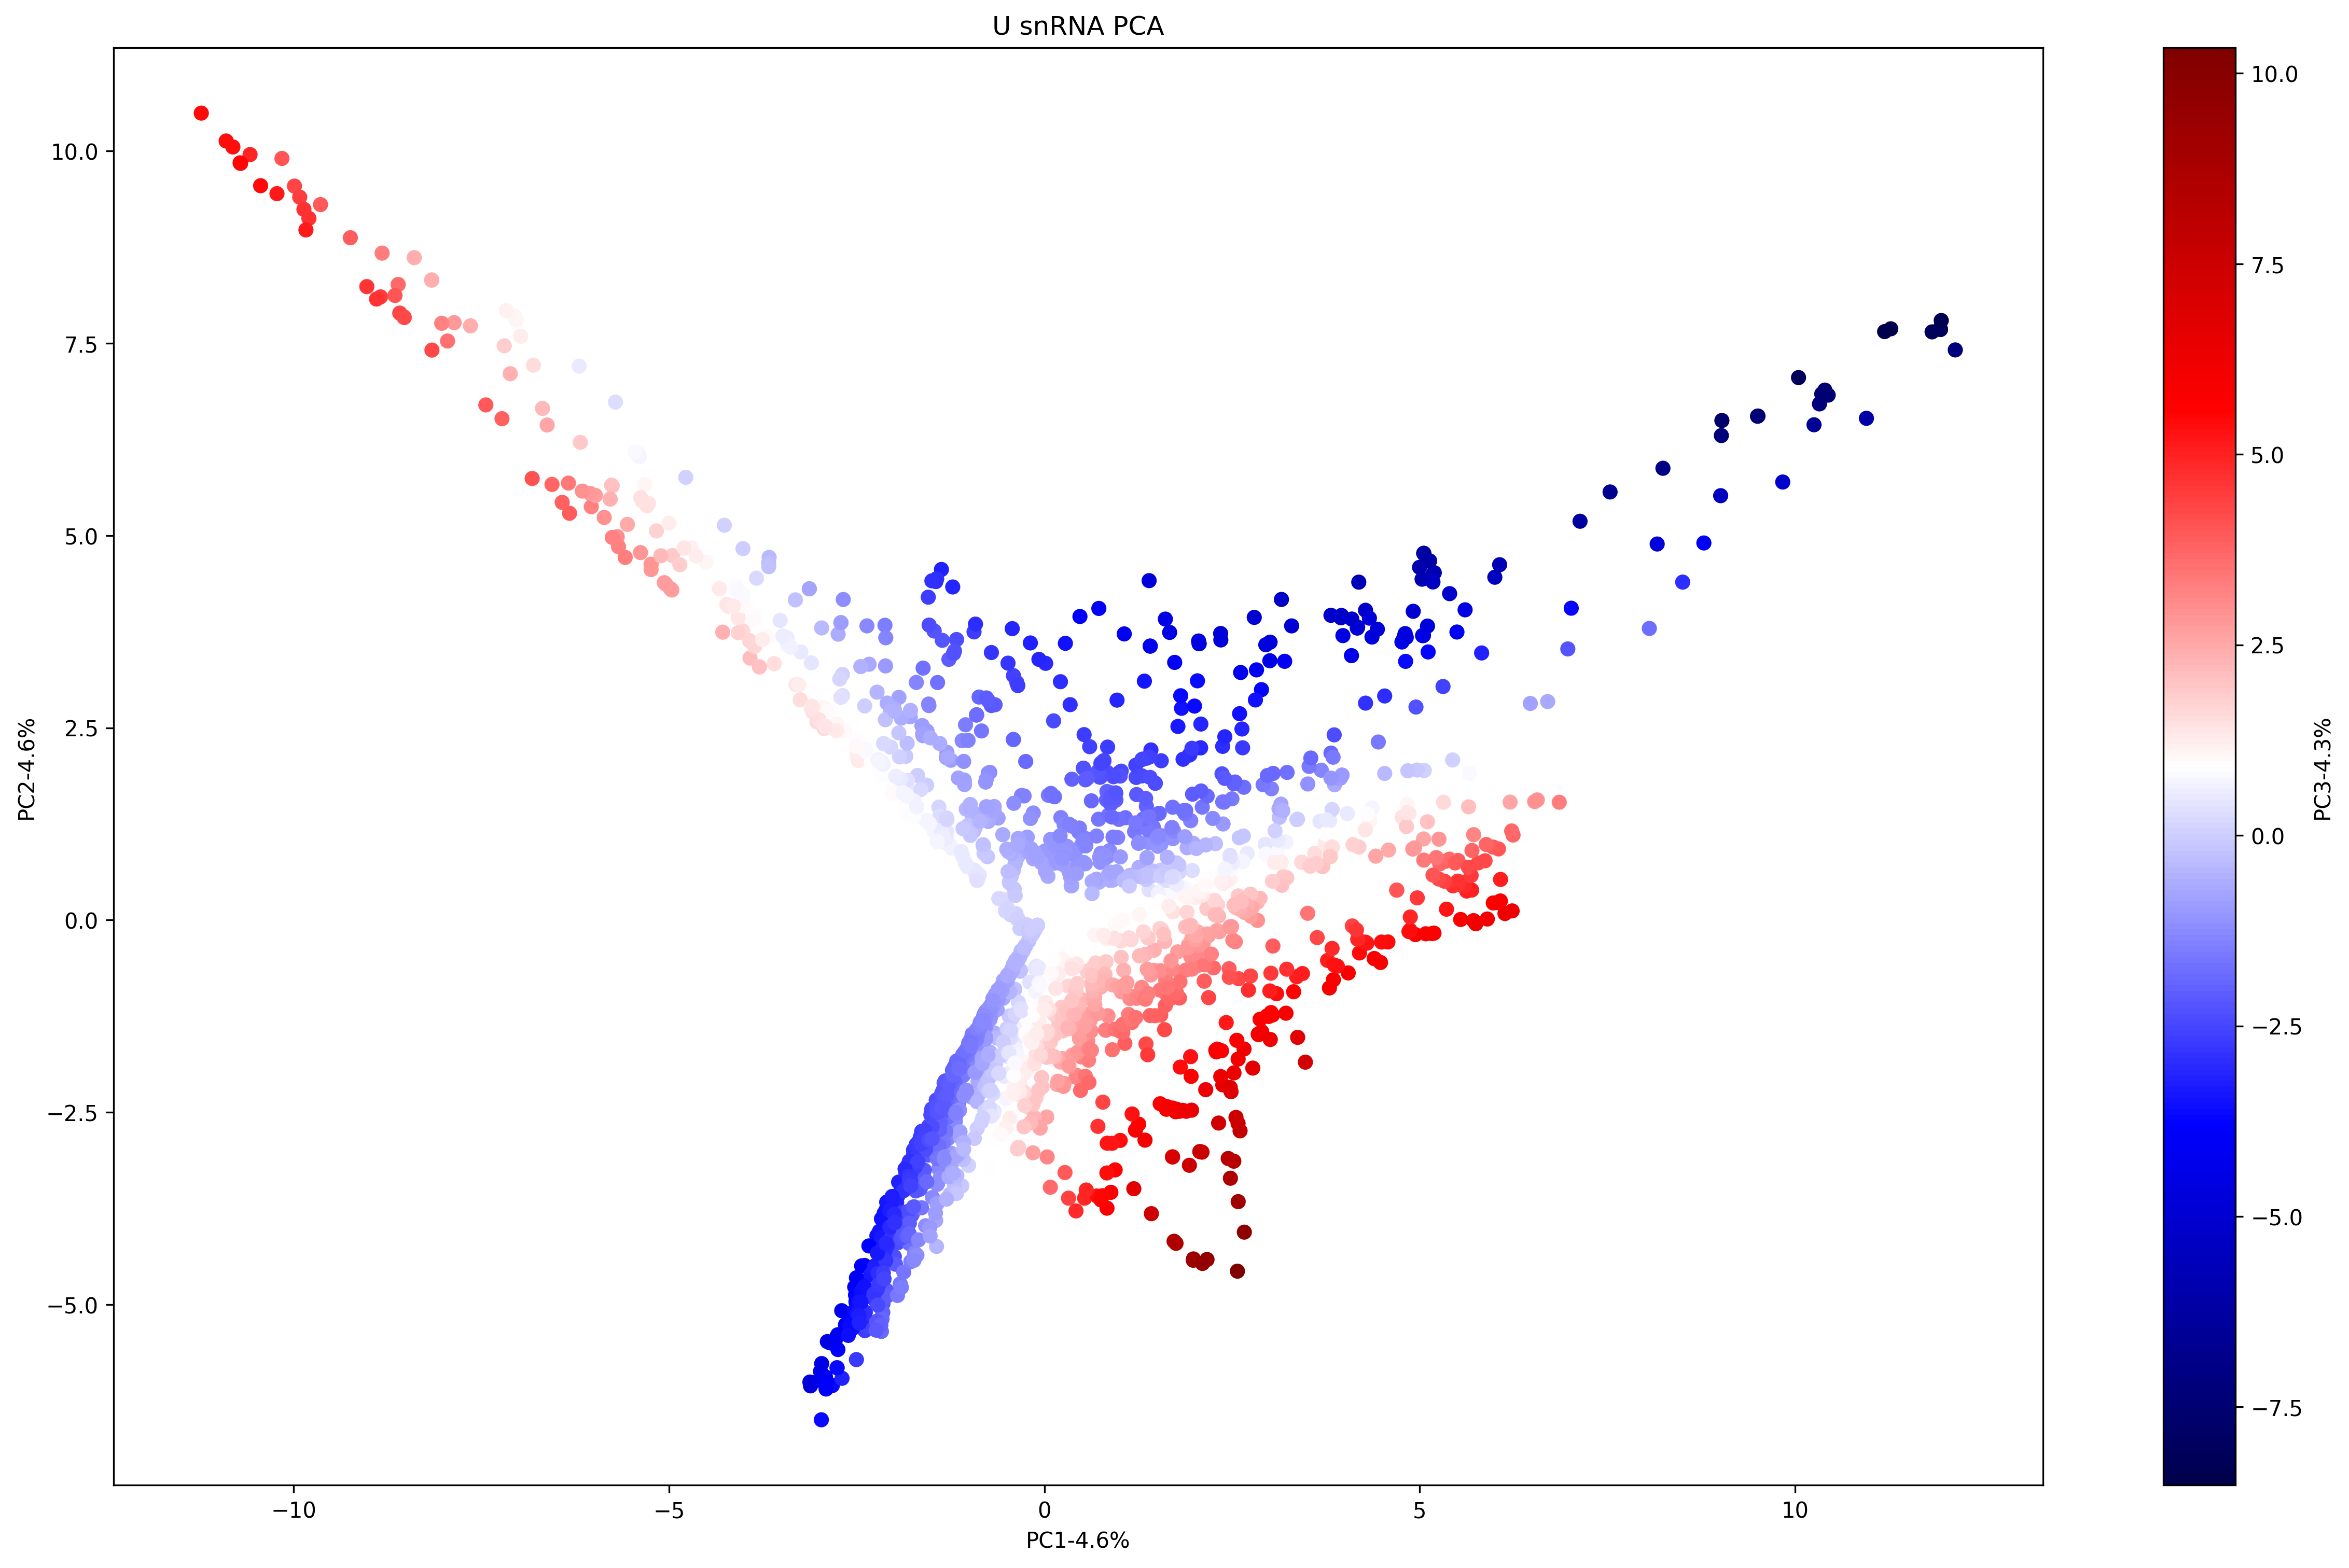

In [ ]:
pca_df = pd.DataFrame(pca_scores, index=pca_matrix.index,
                      columns=[f'PC{i+1}' for i in range(pca_scores.shape[1])])
#pca_df = pd.DataFrame(pca_data, columns=labels)
pca_df.head()
plt.figure(figsize=(20, 12), dpi=300)

plt.title('U snRNA PCA')

scatter = plt.scatter(pca_df['PC1'], pca_df['PC2'], c=pca_df['PC3'], cmap= 'seismic')
plt.xlabel('PC1-{0}%'.format(per_var[0]))
plt.ylabel('PC2-{0}%'.format(per_var[1]))
plt.colorbar(scatter, label='PC3-{0}%'.format(per_var[2]))

# #for sample in pca_df.index:
# plt.annotate(sample, (pca_df['PC1'][sample], pca_df['PC2'][sample]), xytext=(15, 15))
            #  textcoords='offset points',
            #  arrowprops=dict(arrowstyle='->'))
#plt.savefig('snRNA_PCA_03162026.png', dpi=300)
plt.show()

Because it is difficult to make any sense out of this PCA plot, I will use a heat map to look at correalations

In [ ]:
# mt = pca_matrix.T.describe()
# Means = mt.loc['mean']
# M = Means.T
# masks = M > M.mean()
# df = pca_matrix[masks]
# df.shape
# corr = df.T.corr()
# corr.head()
corr = pca_matrix.T.corr()
corr = corr.fillna(0) # Fill NaN values with 0

# print(corr.max().max())
# print(corr.min().min())
# print((corr > 0.5).sum().sum())
# print(M)
#Generate a mask for the triangle

# #mask = np.tril(np.ones_like(corr, dtype=bool))
# mask = np.triu(np.ones_like(corr, dtype=bool),k=1)

# # Set up the matplotlib figure
# f, ax = plt.subplots(figsize=(15, 12))

# # Generate a custom diverging colormap
# cmap = sns.diverging_palette(250, 20, as_cmap=True)

# # Draw the heatmap with the mask and correct aspect ratio
# Heat = sns.heatmap(corr, mask=mask, cmap=cmap, vmax=1, center=0, square=True, linewidths=.5,
#             cbar_kws={"shrink": .5}).set(title='Pairwise Correlation of U snRNA Reactvity Profiles')

sns.clustermap(corr, cmap=cmap, vmax=1, center=0, figsize=(15,12))


/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


KeyboardInterrupt: 

Error in callback <function flush_figures at 0x797c45cca2a0> (for post_execute):


KeyboardInterrupt: 